First 5 rows:
  Employee Department  Salary  Performance  Experience
0     Arun         IT   45000           85           2
1     Bala         HR   40000           78           3
2   Charan         IT   55000           92           5
3    Divya    Finance   50000           88           4
4    Elena         HR   42000           81           2

Missing values:
Employee       0
Department     0
Salary         0
Performance    0
Experience     0
dtype: int64

Summary Statistics:
             Salary  Performance  Experience
count      8.000000     8.000000    8.000000
mean   49000.000000    87.000000    3.625000
std     6697.547526     5.606119    1.407886
min    40000.000000    78.000000    2.000000
25%    44250.000000    84.000000    2.750000
50%    49000.000000    87.500000    3.500000
75%    52750.000000    90.500000    4.250000
max    60000.000000    95.000000    6.000000

Department Summary:
  Department  Salary  Performance
0    Finance  162000         91.0
1         HR   82000      

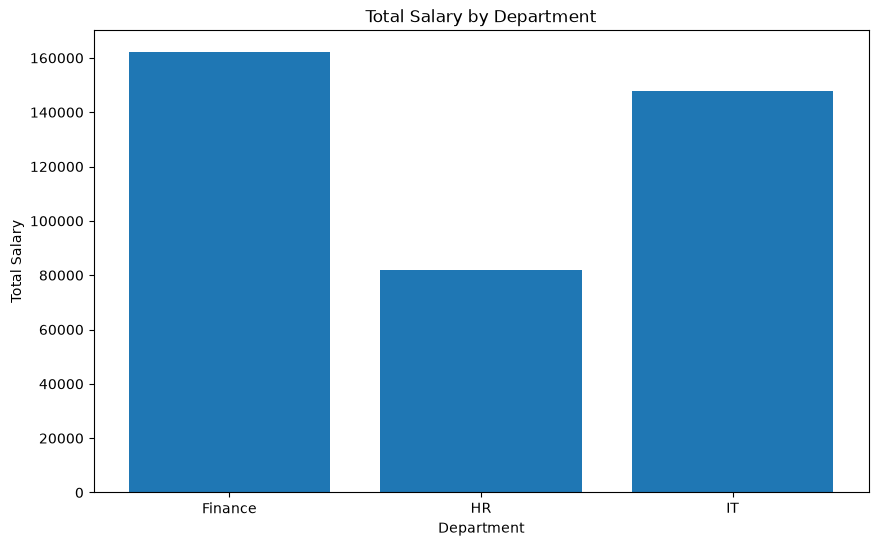

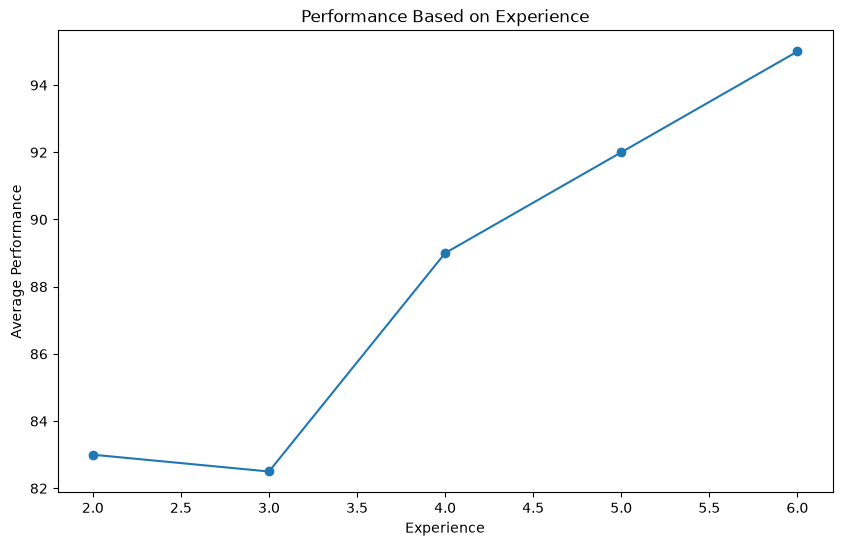


Pivot Table:
Experience     2     3     4     5     6
Department                              
Finance      0.0   0.0  89.0   0.0  95.0
HR          81.0  78.0   0.0   0.0   0.0
IT          85.0  87.0   0.0  92.0   0.0

Correlation Matrix:
               Salary  Performance  Experience
Salary       1.000000     0.985425    0.909013
Performance  0.985425     1.000000    0.832588
Experience   0.909013     0.832588    1.000000


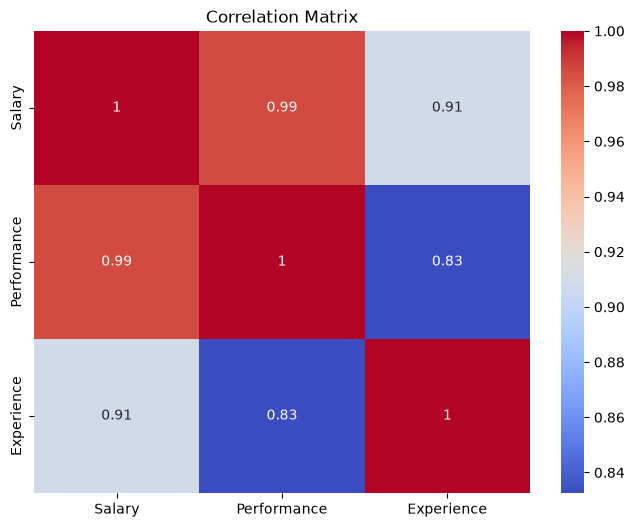

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('employee_data.csv')

print("First 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

df.dropna(subset=['Employee', 'Department', 'Performance'], inplace=True)

print("\nSummary Statistics:")
print(df.describe())
     
department_summary = df.groupby('Department').agg({
    'Salary': 'sum',
    'Performance': 'mean'
}).reset_index()

print("\nDepartment Summary:")
print(department_summary)

plt.figure(figsize=(10, 6))
plt.bar(department_summary['Department'],
        department_summary['Salary'])

plt.xlabel('Department')
plt.ylabel('Total Salary')
plt.title('Total Salary by Department')
plt.show()

performance_over_time = df.groupby('Experience')['Performance'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(performance_over_time['Experience'],
         performance_over_time['Performance'],
         marker='o')

plt.xlabel('Experience')
plt.ylabel('Average Performance')
plt.title('Performance Based on Experience')
plt.show()

pivot_table = df.pivot_table(
    values='Performance',
    index='Department',
    columns='Experience',
    aggfunc='mean',
    fill_value=0
)

print("\nPivot Table:")
print(pivot_table)

correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()